In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt


In [ ]:
enrol_files = glob.glob("api_data_aadhar_enrolment*.csv")
bio_files   = glob.glob("api_data_aadhar_biometric*.csv")
demo_files  = glob.glob("api_data_aadhar_demographic*.csv")

print("Enrolment files:", len(enrol_files))
print("Biometric files:", len(bio_files))
print("Demographic files:", len(demo_files))

enroll = pd.concat([pd.read_csv(f) for f in enrol_files], ignore_index=True)
bio    = pd.concat([pd.read_csv(f) for f in bio_files], ignore_index=True)
demo   = pd.concat([pd.read_csv(f) for f in demo_files], ignore_index=True)


Enrolment files: 3
Biometric files: 4
Demographic files: 5


In [ ]:
for df in [enroll, bio, demo]:
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    df['year_month'] = df['date'].dt.to_period('M')


In [ ]:
enroll_agg = enroll.groupby(
    ['state','district','year_month']
).agg(
    enrol_0_5 = ('age_0_5','sum'),
    enrol_5_17 = ('age_5_17','sum'),
    enrol_18_plus = ('age_18_greater','sum')
).reset_index()

enroll_agg['total_enrol'] = (
    enroll_agg['enrol_0_5'] +
    enroll_agg['enrol_5_17'] +
    enroll_agg['enrol_18_plus']
)


In [ ]:
bio_agg = bio.groupby(
    ['state','district','year_month']
).agg(
    bio_5_17 = ('bio_age_5_17','sum'),
    bio_18_plus = ('bio_age_17_','sum')
).reset_index()

bio_agg['total_bio'] = bio_agg['bio_5_17'] + bio_agg['bio_18_plus']


In [ ]:
demo_agg = demo.groupby(
    ['state','district','year_month']
).agg(
    demo_5_17 = ('demo_age_5_17','sum'),
    demo_18_plus = ('demo_age_17_','sum')
).reset_index()

demo_agg['total_demo'] = demo_agg['demo_5_17'] + demo_agg['demo_18_plus']


In [ ]:
df = enroll_agg.merge(
    bio_agg, on=['state','district','year_month'], how='left'
).merge(
    demo_agg, on=['state','district','year_month'], how='left'
)

df.fillna(0, inplace=True)


In [ ]:
df['DUR'] = (df['total_demo'] / df['total_enrol']) * 1000
df['BUI'] = (df['total_bio'] / df['total_enrol']) * 1000

df['CLP'] = (
    (df['bio_5_17'] + df['demo_5_17']) / df['enrol_5_17']
) * 1000

df['MDR'] = (df['total_demo'] + df['total_bio']) / df['total_enrol']

df.replace([np.inf, -np.inf], 0, inplace=True)


In [ ]:
metrics = ['DUR','BUI','CLP','MDR']

for m in metrics:
    df[m+'_norm'] = (df[m] - df[m].min()) / (df[m].max() - df[m].min())


In [ ]:
df['AUFI'] = df[[m+'_norm' for m in metrics]].mean(axis=1)


In [ ]:
df.sort_values('AUFI', ascending=False)[
    ['state','district','year_month','AUFI']
].head(15)


,state,district,year_month,AUFI
2781,Maharashtra,Thane,2025-03,0.892780
1108,Delhi,North West Delhi,2025-03,0.668484
2729,Maharashtra,Pune,2025-04,0.590708
4444,Uttar Pradesh,Gorakhpur,2025-03,0.353390
726,Bihar,Muzaffarpur,2025-03,0.340133
4354,Uttar Pradesh,Bulandshahr,2025-03,0.314186
617,Bihar,Bhagalpur,2025-03,0.306356
753,Bihar,Patna,2025-03,0.296815
3430,Punjab,Amritsar,2025-03,0.286454
1170,Gujarat,Ahmedabad,2025-04,0.240651


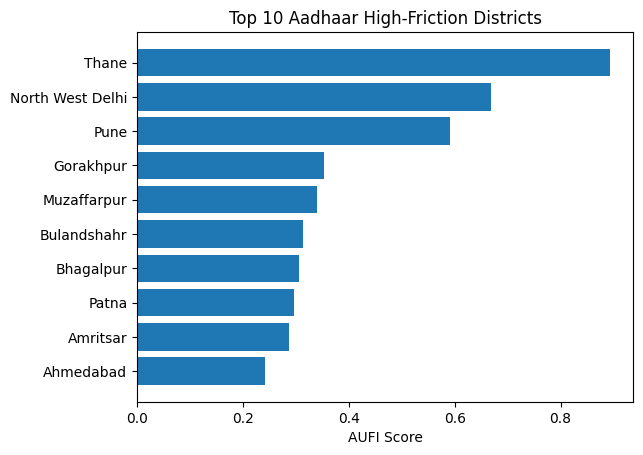

In [ ]:
top = df.sort_values('AUFI', ascending=False).head(10)

plt.barh(top['district'], top['AUFI'])
plt.xlabel("AUFI Score")
plt.title("Top 10 Aadhaar High-Friction Districts")
plt.gca().invert_yaxis()
plt.show()


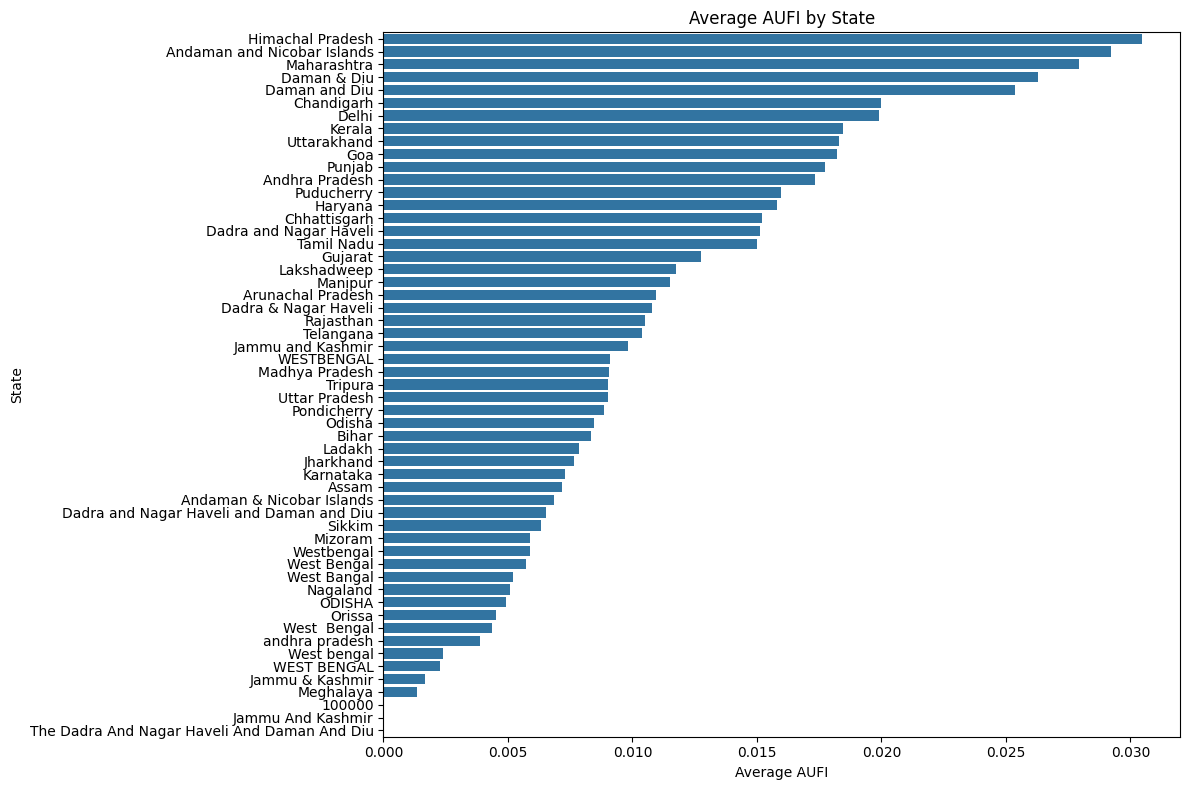

In [ ]:
state_aufi = (
    df.groupby('state')['AUFI']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 8))
sns.barplot(data=state_aufi, x='AUFI', y='state')
plt.title('Average AUFI by State')
plt.xlabel('Average AUFI')
plt.ylabel('State')
plt.tight_layout()
plt.show()

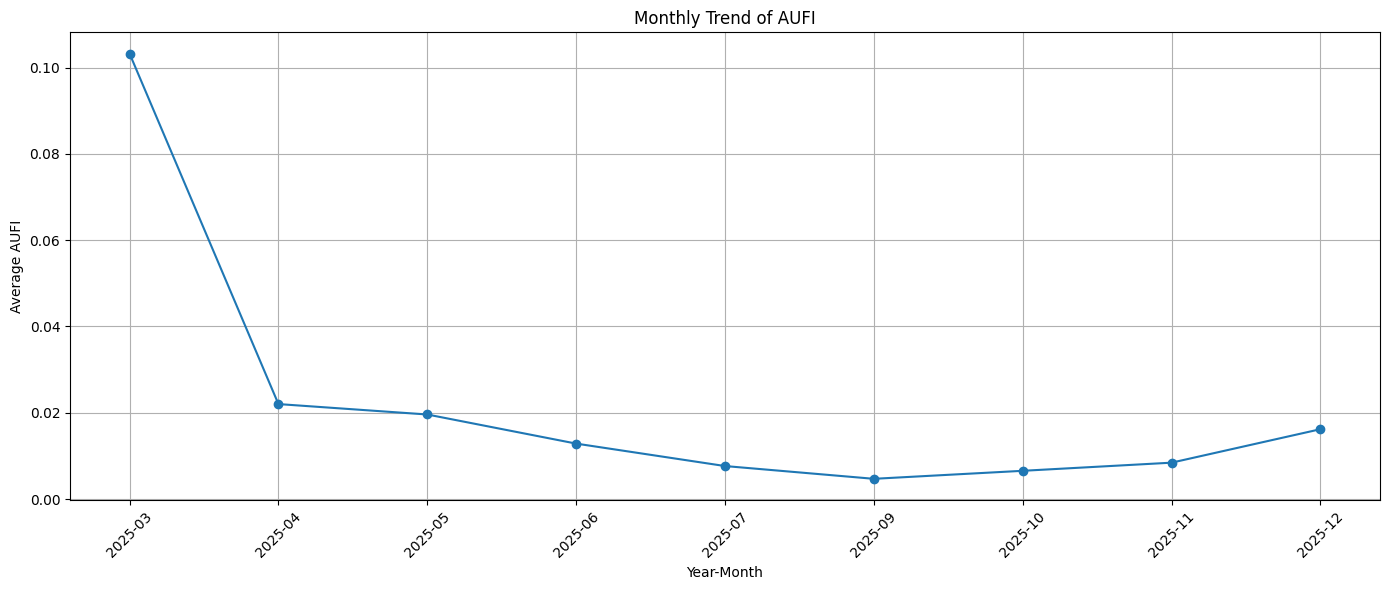

In [ ]:
monthly_aufi = (
    df.groupby('year_month')['AUFI']
    .mean()
    .reset_index()
)

monthly_aufi['year_month'] = monthly_aufi['year_month'].astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly_aufi['year_month'], monthly_aufi['AUFI'], marker='o')
plt.title('Monthly Trend of AUFI')
plt.xlabel('Year-Month')
plt.ylabel('Average AUFI')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

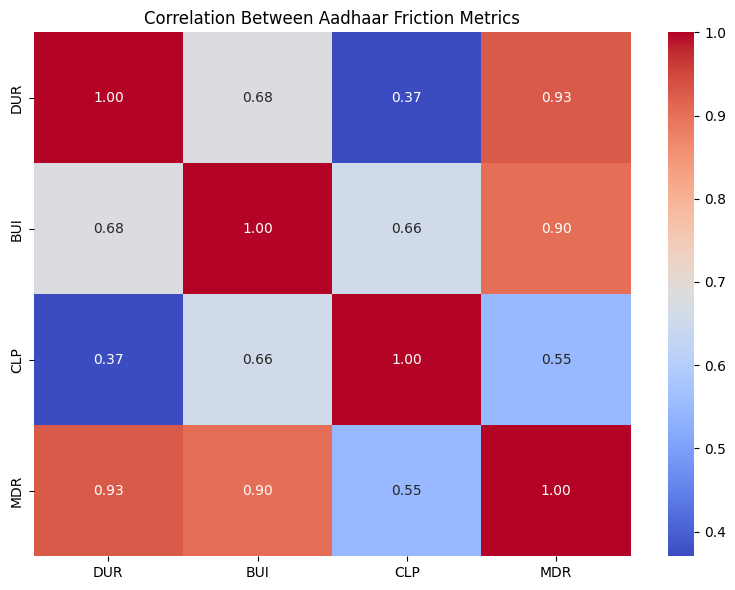

In [ ]:
metrics = ['DUR', 'BUI', 'CLP', 'MDR']

plt.figure(figsize=(8, 6))
sns.heatmap(df[metrics].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Aadhaar Friction Metrics')
plt.tight_layout()
plt.show()

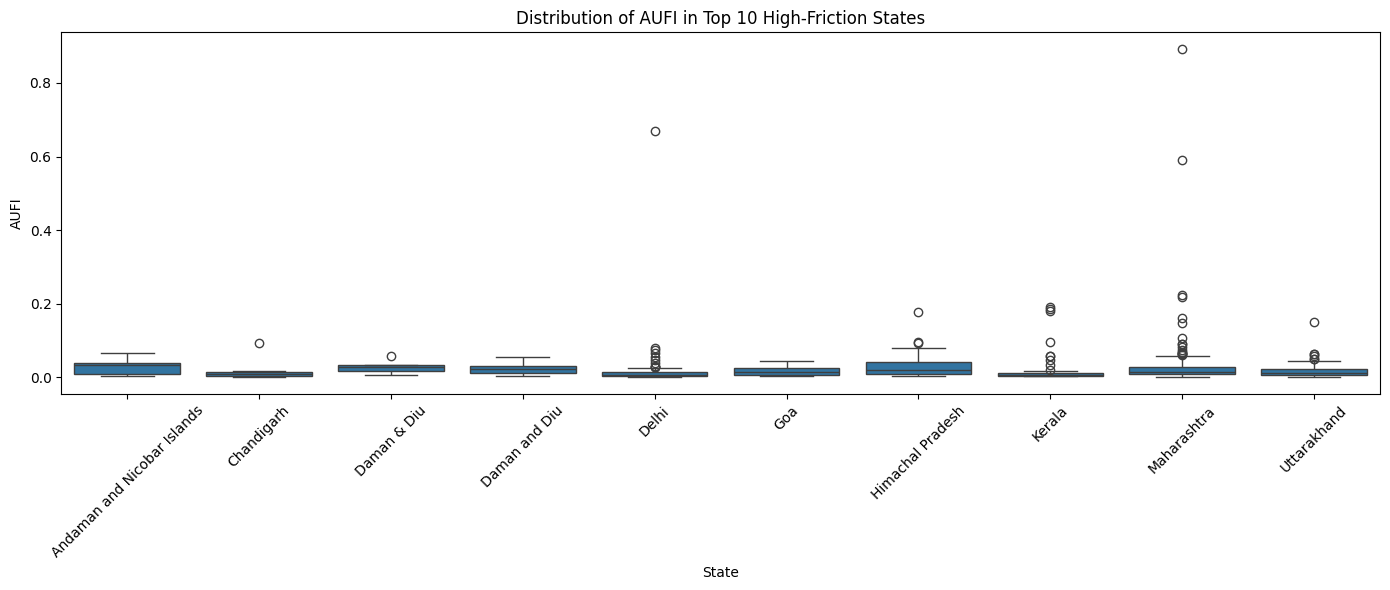

In [ ]:
# Select top 10 states by average AUFI for readability
top_states = (
    df.groupby('state')['AUFI']
    .mean()
    .nlargest(10)
    .index
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df[df['state'].isin(top_states)],
    x='state',
    y='AUFI'
)
plt.title('Distribution of AUFI in Top 10 High-Friction States')
plt.xlabel('State')
plt.ylabel('AUFI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

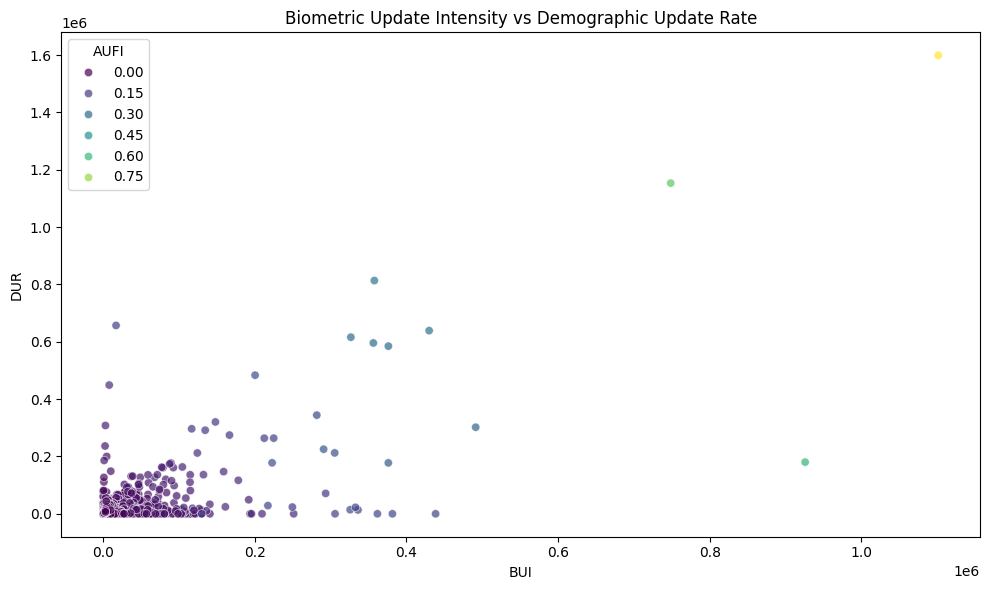

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='BUI',
    y='DUR',
    hue='AUFI',
    palette='viridis',
    alpha=0.7
)
plt.title('Biometric Update Intensity vs Demographic Update Rate')
plt.xlabel('BUI')
plt.ylabel('DUR')
plt.tight_layout()
plt.show()

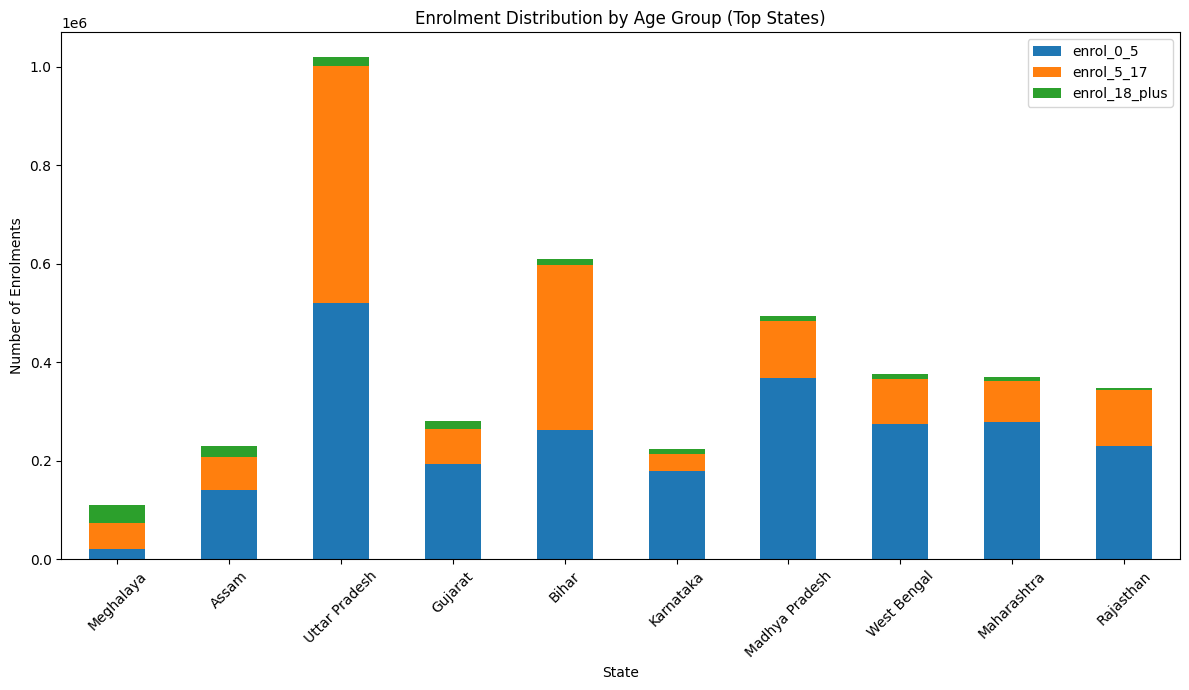

In [ ]:
age_group_state = (
    df.groupby('state')[['enrol_0_5', 'enrol_5_17', 'enrol_18_plus']]
    .sum()
    .sort_values(by='enrol_18_plus', ascending=False)
    .head(10)
)

age_group_state.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)
plt.title('Enrolment Distribution by Age Group (Top States)')
plt.xlabel('State')
plt.ylabel('Number of Enrolments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

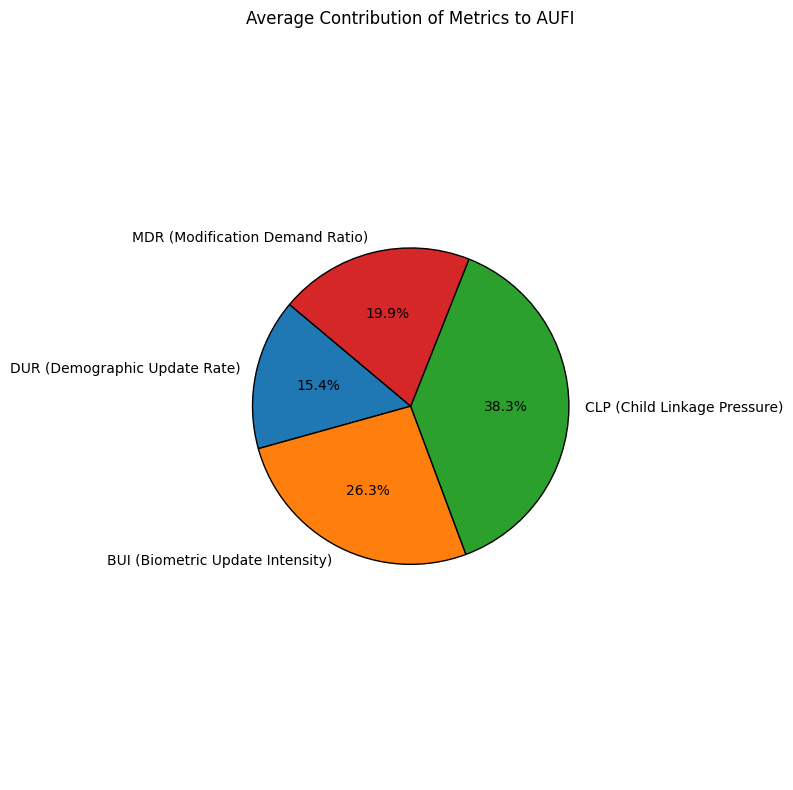

In [ ]:
import matplotlib.pyplot as plt

# Average contribution of each normalized metric
metric_cols = ['DUR_norm', 'BUI_norm', 'CLP_norm', 'MDR_norm']
metric_means = df[metric_cols].mean()

# Labels for better readability
labels = ['DUR (Demographic Update Rate)',
          'BUI (Biometric Update Intensity)',
          'CLP (Child Linkage Pressure)',
          'MDR (Modification Demand Ratio)']

plt.figure(figsize=(8, 8))
plt.pie(
    metric_means,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)
plt.title('Average Contribution of Metrics to AUFI')
plt.axis('equal')  # Ensures the pie chart is circular
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

40.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

48.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

57.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

43.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

45.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categor

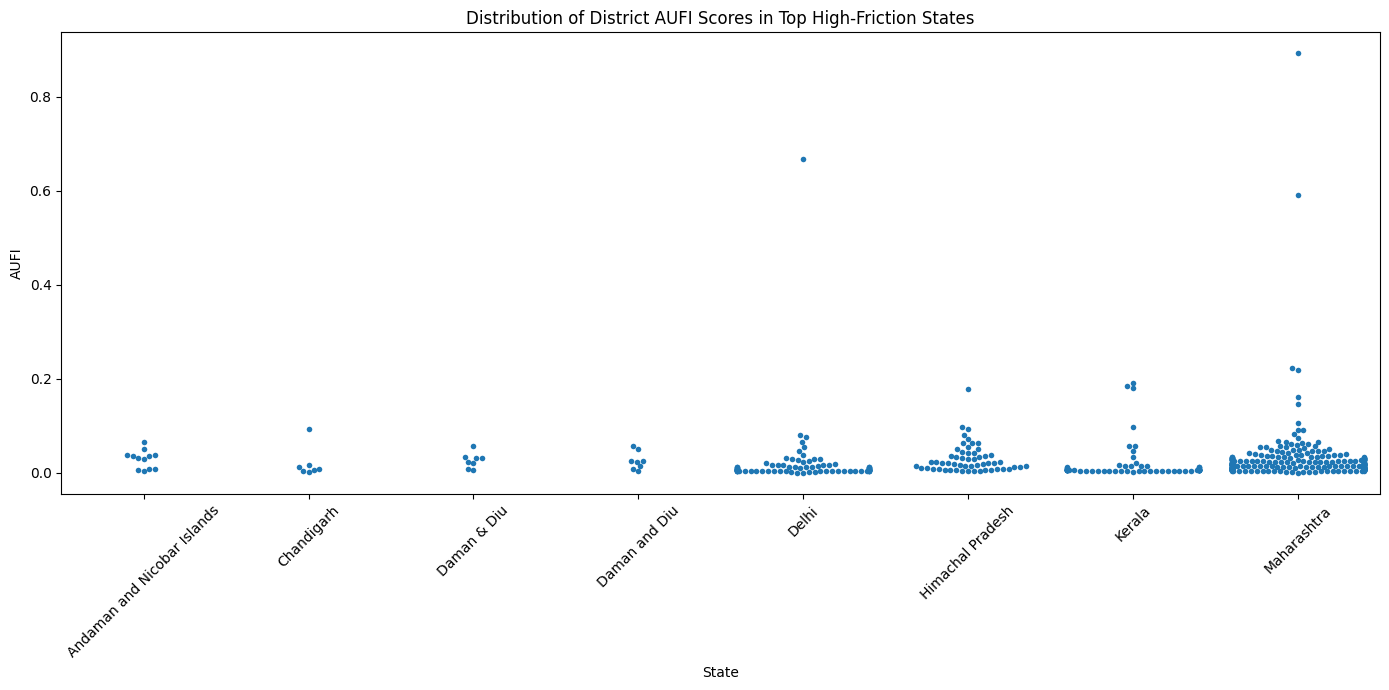

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select top 8 states by average AUFI for clarity
top_states = (
    df.groupby('state')['AUFI']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plt.figure(figsize=(14, 7))
sns.swarmplot(
    data=df[df['state'].isin(top_states)],
    x='state',
    y='AUFI',
    size=4
)

plt.title('Distribution of District AUFI Scores in Top High-Friction States')
plt.xlabel('State')
plt.ylabel('AUFI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

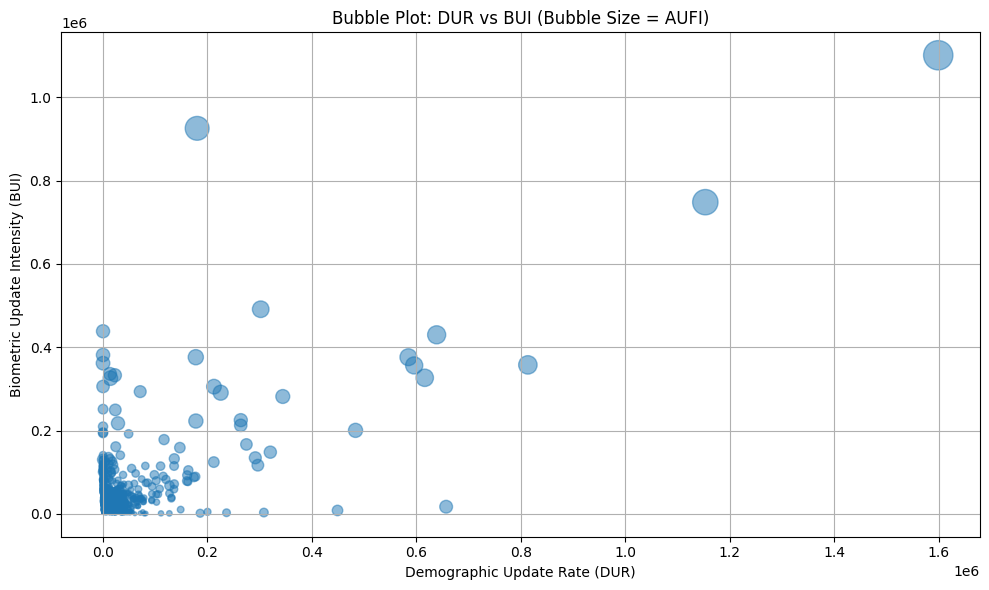

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df['DUR'],
    df['BUI'],
    s=df['AUFI'] * 500,  # Bubble size
    alpha=0.5
)
plt.title('Bubble Plot: DUR vs BUI (Bubble Size = AUFI)')
plt.xlabel('Demographic Update Rate (DUR)')
plt.ylabel('Biometric Update Intensity (BUI)')
plt.grid(True)
plt.tight_layout()
plt.show()